In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16,6)

In [2]:
file_path = "./buoy/jennettespier2025.txt"

# read file ignoring header lines starting with #
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    comment="#"
)

df.head()

C:\Users\monaz\AppData\Local\Temp\ipykernel_13432\3312781001.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,2025,01,01.1,00,26,999,99.0,99.0.1,1.32,5.56,4.89,134,9999.0,999.0,10.9,999.0.1,99.0.2,99.00
0,2025,1,1,0,56,999,99.0,99.0,1.40,6.25,5.20,121,9999.0,999.0,10.9,999.0,99.0,99.0
1,2025,1,1,1,26,999,99.0,99.0,1.32,5.88,4.96,120,9999.0,999.0,10.8,999.0,99.0,99.0
2,2025,1,1,1,56,999,99.0,99.0,1.30,5.88,4.83,131,9999.0,999.0,10.8,999.0,99.0,99.0
3,2025,1,1,2,26,999,99.0,99.0,1.22,6.25,4.83,117,9999.0,999.0,11.0,999.0,99.0,99.0
4,2025,1,1,2,56,999,99.0,99.0,1.17,5.26,4.75,139,9999.0,999.0,11.1,999.0,99.0,99.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "./buoy/jennettespier2025.txt"

# Read the first header line manually
with open(file_path, "r") as f:
    first_header = f.readline().strip()

# Build column names from the first header line
columns = first_header.lstrip("#").split()

# Read the actual data, skipping both header lines
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    skiprows=2,
    names=columns
)

print(df.head())
print(df.columns)
df["datetime"] = pd.to_datetime(
    dict(
        year=df["YY"],
        month=df["MM"],
        day=df["DD"],
        hour=df["hh"],
        minute=df["mm"]
    )
)

df = df.sort_values("datetime").reset_index(drop=True)

     YY  MM  DD  hh  mm  WDIR  WSPD   GST  WVHT   DPD   APD  MWD    PRES  \
0  2025   1   1   0  26   999  99.0  99.0  1.32  5.56  4.89  134  9999.0   
1  2025   1   1   0  56   999  99.0  99.0  1.40  6.25  5.20  121  9999.0   
2  2025   1   1   1  26   999  99.0  99.0  1.32  5.88  4.96  120  9999.0   
3  2025   1   1   1  56   999  99.0  99.0  1.30  5.88  4.83  131  9999.0   
4  2025   1   1   2  26   999  99.0  99.0  1.22  6.25  4.83  117  9999.0   

    ATMP  WTMP   DEWP   VIS  TIDE  
0  999.0  10.9  999.0  99.0  99.0  
1  999.0  10.9  999.0  99.0  99.0  
2  999.0  10.8  999.0  99.0  99.0  
3  999.0  10.8  999.0  99.0  99.0  
4  999.0  11.0  999.0  99.0  99.0  
Index(['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
       'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'],
      dtype='object')


C:\Users\monaz\AppData\Local\Temp\ipykernel_13432\301278645.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [4]:
missing_vals = [99, 99.0, 999, 999.0, 9999, 9999.0]

df["WVHT"] = df["WVHT"].replace(missing_vals, np.nan)
df["DPD"] = df["DPD"].replace(missing_vals, np.nan)

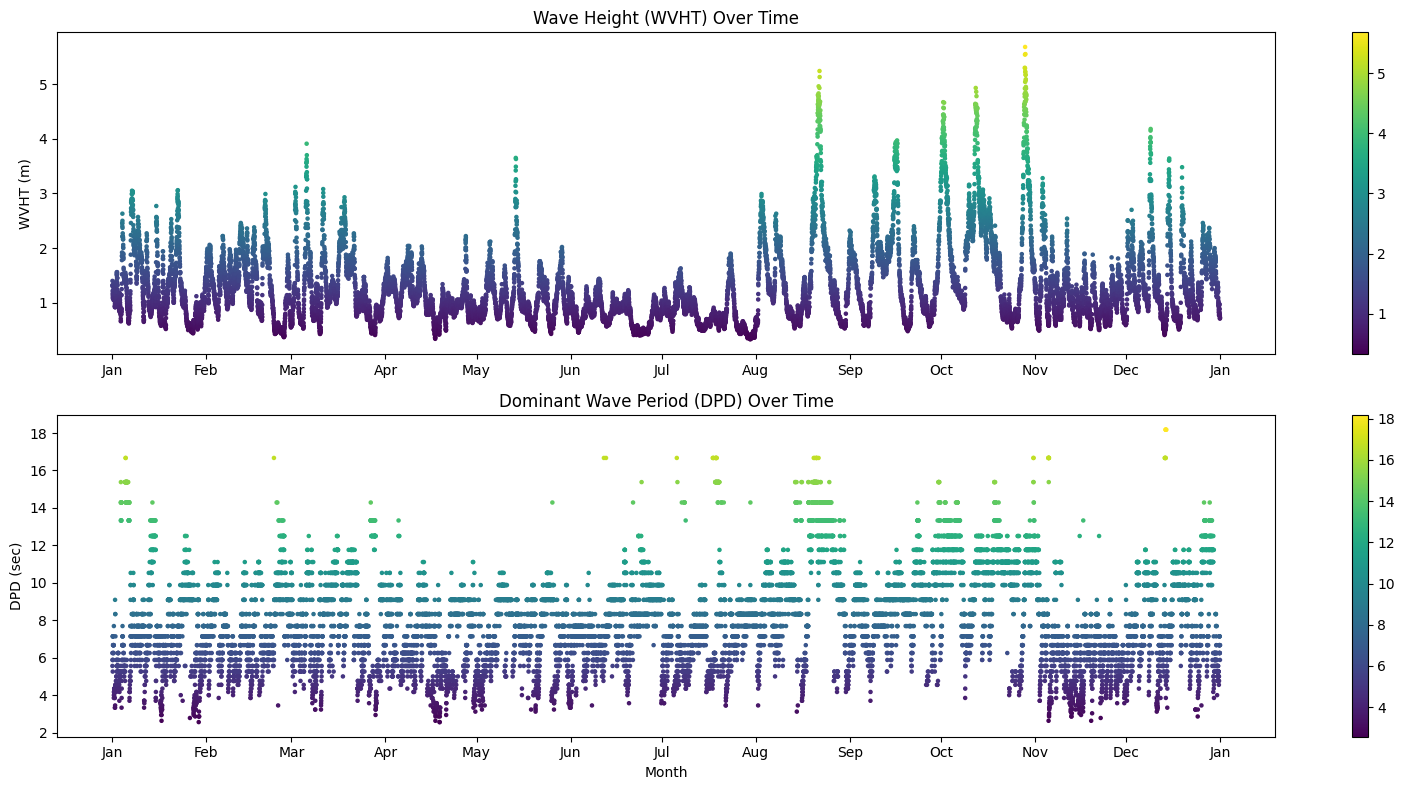

In [5]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(2,1, figsize=(16,8))

# WVHT
sc1 = ax[0].scatter(df["datetime"], df["WVHT"], c=df["WVHT"], s=5)
ax[0].set_title("Wave Height (WVHT) Over Time")
ax[0].set_ylabel("WVHT (m)")
fig.colorbar(sc1, ax=ax[0])

# DPD
sc2 = ax[1].scatter(df["datetime"], df["DPD"], c=df["DPD"], s=5)
ax[1].set_title("Dominant Wave Period (DPD) Over Time")
ax[1].set_ylabel("DPD (sec)")
fig.colorbar(sc2, ax=ax[1])

# Format x-axis to show months
for a in ax:
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

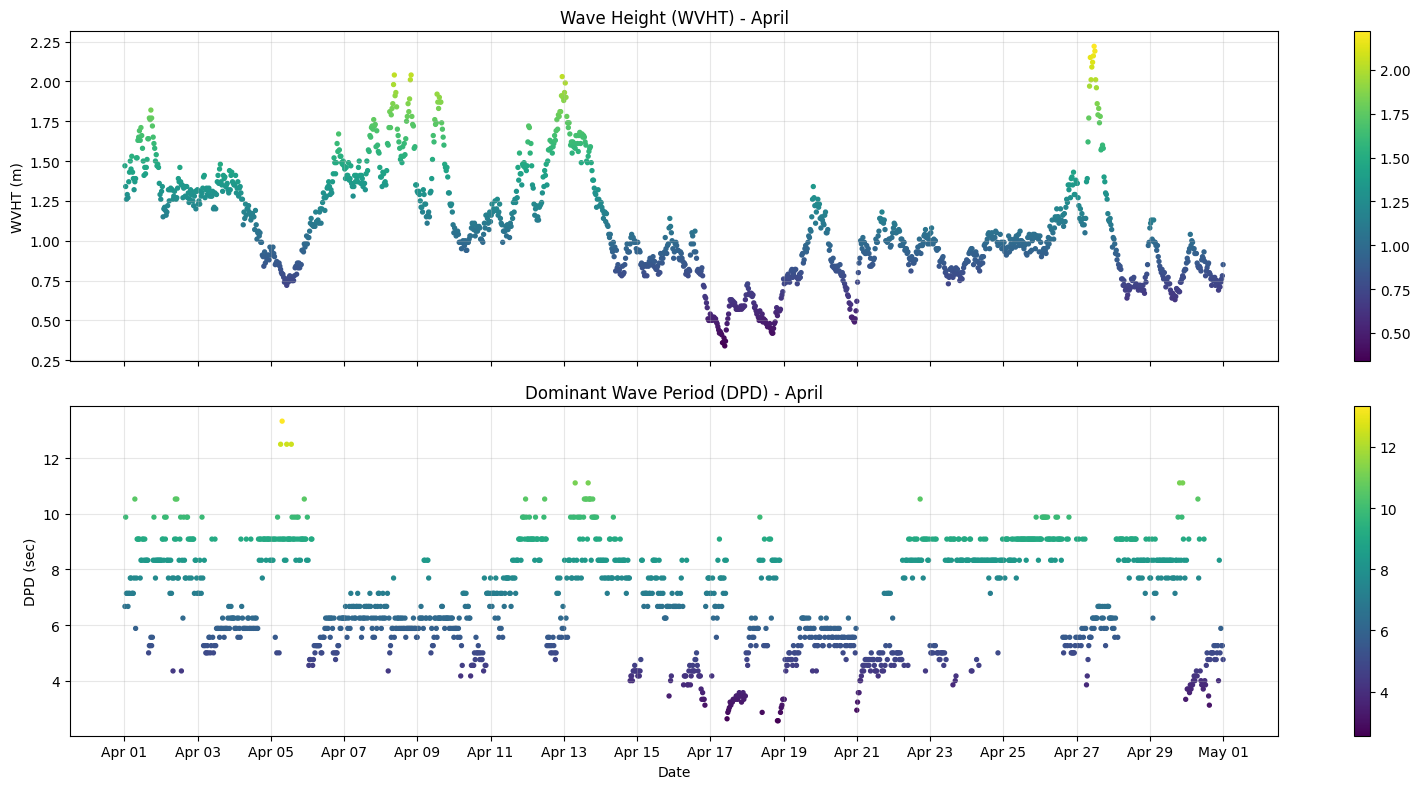

In [6]:
# Plot only one selected month (1=Jan ... 12=Dec)
import calendar
import matplotlib.dates as mdates

selected_month = 4  # change this to the month you want

df_month = df[df["datetime"].dt.month == selected_month].copy()

if df_month.empty:
    print(f"No data found for month {selected_month} ({calendar.month_name[selected_month]}).")
else:
    fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    sc1 = ax[0].scatter(df_month["datetime"], df_month["WVHT"], c=df_month["WVHT"], s=8)
    ax[0].set_title(f"Wave Height (WVHT) - {calendar.month_name[selected_month]}")
    ax[0].set_ylabel("WVHT (m)")
    fig.colorbar(sc1, ax=ax[0])

    sc2 = ax[1].scatter(df_month["datetime"], df_month["DPD"], c=df_month["DPD"], s=8)
    ax[1].set_title(f"Dominant Wave Period (DPD) - {calendar.month_name[selected_month]}")
    ax[1].set_ylabel("DPD (sec)")
    fig.colorbar(sc2, ax=ax[1])

    for a in ax:
        a.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        a.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        a.grid(alpha=0.3)

    ax[1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

In [7]:
import pandas as pd
import numpy as np

# -------------------------
# assuming df is already loaded and datetime already created
# -------------------------

# Clean missing values
missing_vals = [99, 99.0, 99.00, 999, 999.0, 9999, 9999.0]
for col in ["WVHT", "DPD", "MWD"]:
    df[col] = df[col].replace(missing_vals, np.nan)

# keep only what you care about
table_df = df[["datetime", "WVHT", "DPD", "MWD"]].copy()

# optional: round values for display
table_df["WVHT"] = table_df["WVHT"].round(2)
table_df["DPD"] = table_df["DPD"].round(2)
table_df["MWD"] = table_df["MWD"].round(0)

# If full year is too huge, preview first 200 rows
preview_df = table_df.head(200)

styled = (
    preview_df.style
    .format({
        "datetime": lambda x: x.strftime("%Y-%m-%d %H:%M"),
        "WVHT": "{:.2f}",
        "DPD": "{:.2f}",
        "MWD": "{:.0f}"
    })
    .background_gradient(subset=["WVHT"], cmap="YlGnBu")
    .background_gradient(subset=["DPD"], cmap="YlOrRd")
    .background_gradient(subset=["MWD"], cmap="PuRd")
)

In [8]:
styled

,datetime,WVHT,DPD,MWD
0,2025-01-01 00:26,1.32,5.56,134
1,2025-01-01 00:56,1.40,6.25,121
2,2025-01-01 01:26,1.32,5.88,120
3,2025-01-01 01:56,1.30,5.88,131
4,2025-01-01 02:26,1.22,6.25,117
5,2025-01-01 02:56,1.17,5.26,139
6,2025-01-01 03:26,1.13,7.14,124
7,2025-01-01 03:56,1.08,7.14,107
8,2025-01-01 04:26,1.10,7.14,121
9,2025-01-01 04:56,1.15,6.67,130


In [9]:
heat_df = df[["datetime","WVHT","DPD"]].copy()

heat_df["date"] = heat_df["datetime"].dt.date
heat_df["time"] = heat_df["datetime"].dt.strftime("%H:%M")

wvht_grid = heat_df.pivot_table(
    index="date",
    columns="time",
    values="WVHT",
    aggfunc="mean"
)

dpd_grid = heat_df.pivot_table(
    index="date",
    columns="time",
    values="DPD",
    aggfunc="mean"
)

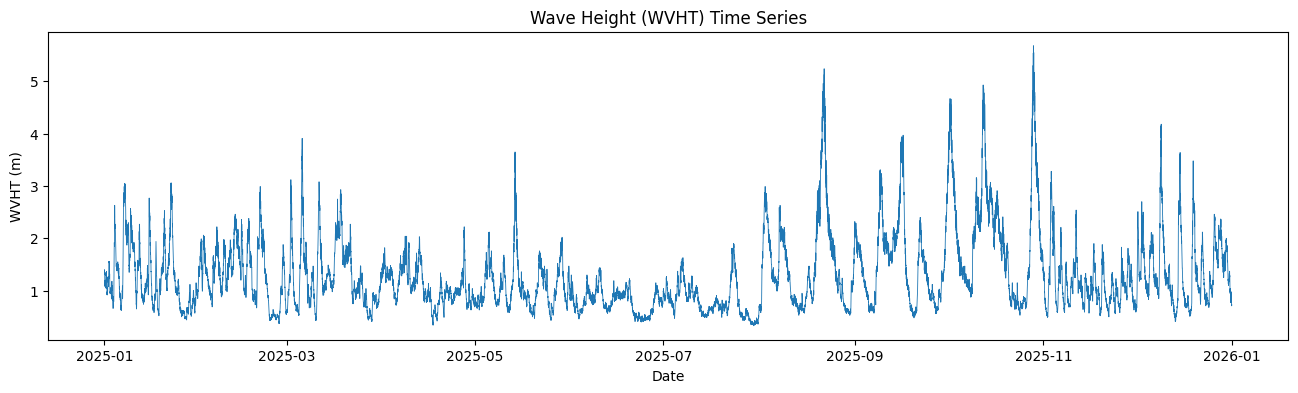

In [10]:
plt.figure(figsize=(16,4))

plt.plot(df["datetime"], df["WVHT"], linewidth=0.6)

plt.title("Wave Height (WVHT) Time Series")
plt.ylabel("WVHT (m)")
plt.xlabel("Date")

plt.show()

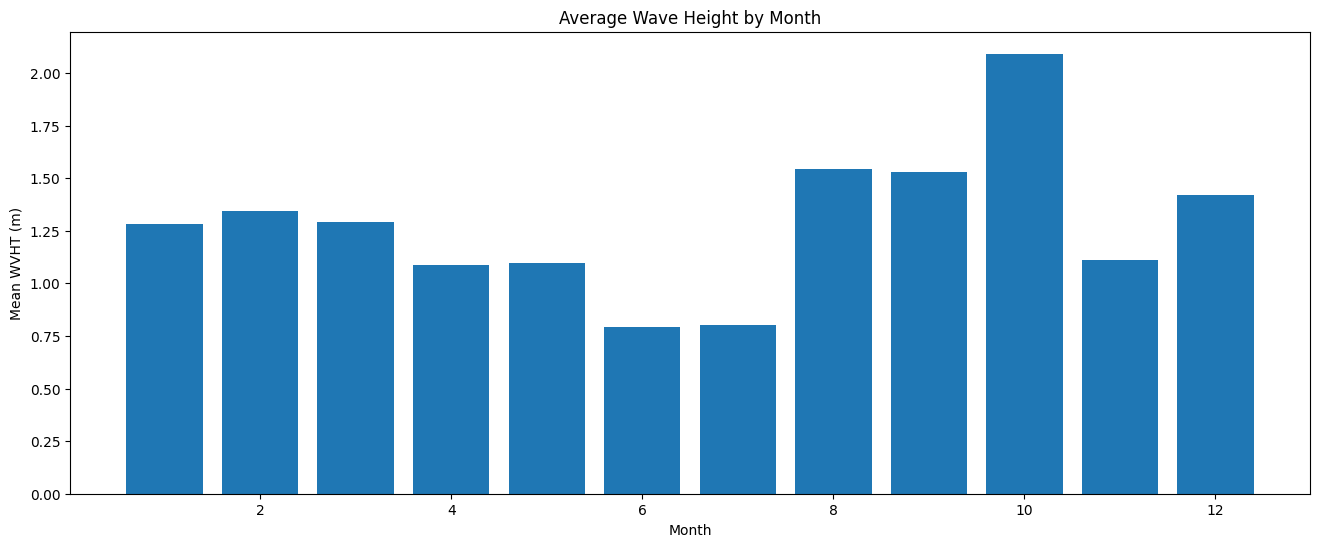

In [11]:
df["month"] = df["datetime"].dt.month

monthly = df.groupby("month")["WVHT"].mean()

plt.bar(monthly.index, monthly.values)

plt.xlabel("Month")
plt.ylabel("Mean WVHT (m)")
plt.title("Average Wave Height by Month")

plt.show()

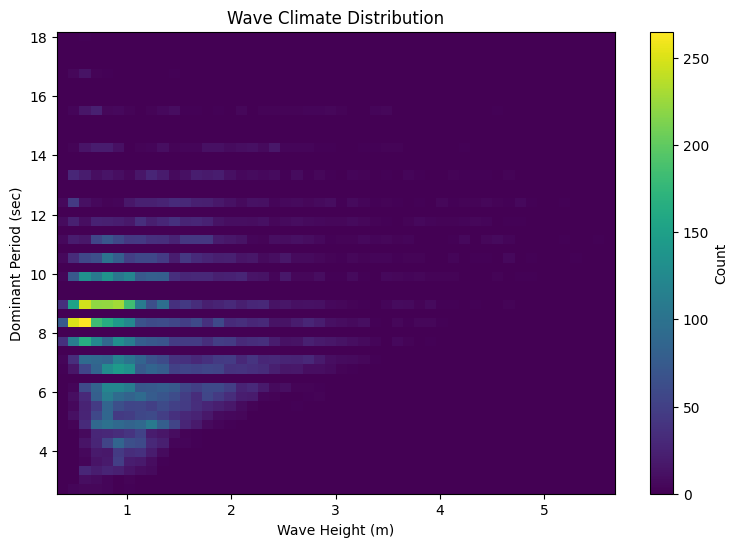

In [12]:
plt.figure(figsize=(9,6))

plt.hist2d(df["WVHT"], df["DPD"], bins=50)

plt.xlabel("Wave Height (m)")
plt.ylabel("Dominant Period (sec)")
plt.title("Wave Climate Distribution")

plt.colorbar(label="Count")

plt.show()

## Daily Wave-Energy Classification (Calm / Mild / Active)

This section uses both wave height (`WVHT`) and dominant period (`DPD`) to classify each day.

Energy proxy used:
`energy_proxy = WVHT^2 * DPD`

Why this helps:
- `WVHT` captures wave size
- `DPD` captures wave period (longer-period swell carries more energy)
- Combining both gives a better "active vs calm" signal than height alone

In [13]:
# Build daily metrics and classify days
import pandas as pd
import numpy as np

work = df[["datetime", "WVHT", "DPD"]].copy()
work = work.dropna(subset=["WVHT", "DPD"]).copy()
work["date"] = work["datetime"].dt.date

# Wave-energy proxy (relative index, not absolute physical power units)
work["energy_proxy"] = (work["WVHT"] ** 2) * work["DPD"]

daily = (
    work.groupby("date", as_index=False)
    .agg(
        wvht_mean=("WVHT", "mean"),
        wvht_p90=("WVHT", lambda s: s.quantile(0.90)),
        wvht_max=("WVHT", "max"),
        dpd_mean=("DPD", "mean"),
        dpd_p90=("DPD", lambda s: s.quantile(0.90)),
        energy_mean=("energy_proxy", "mean"),
        energy_p90=("energy_proxy", lambda s: s.quantile(0.90)),
        n_obs=("energy_proxy", "size"),
    )
)

# Use quantiles so classes adapt to this station/year distribution
q_low = daily["energy_mean"].quantile(0.33)
q_high = daily["energy_mean"].quantile(0.66)

bins = [-np.inf, q_low, q_high, np.inf]
labels = ["calm", "mild", "active"]
daily["energy_class"] = pd.cut(daily["energy_mean"], bins=bins, labels=labels, include_lowest=True)

# Optional sea-state class from height only (WMO-like quick interpretation)
def wmo_height_class(h):
    if pd.isna(h):
        return np.nan
    if h < 0.1:
        return "Calm"
    if h < 0.5:
        return "Smooth"
    if h < 1.25:
        return "Slight"
    if h < 2.5:
        return "Moderate"
    if h < 4.0:
        return "Rough"
    return "Very rough+"

daily["height_state"] = daily["wvht_mean"].apply(wmo_height_class)

# Make datetime for plotting
DailyDate = pd.to_datetime(daily["date"])
daily["date_dt"] = DailyDate

print("Daily energy thresholds (energy_mean):")
print(f"  calm <= {q_low:.3f}")
print(f"  mild: {q_low:.3f} to {q_high:.3f}")
print(f"  active > {q_high:.3f}")

daily.head(10)

Daily energy thresholds (energy_mean):
  calm <= 5.788
  mild: 5.788 to 14.980
  active > 14.980


,date,wvht_mean,wvht_p90,wvht_max,dpd_mean,dpd_p90,energy_mean,energy_p90,n_obs,energy_class,height_state,date_dt
0,2025-01-01,1.148542,1.323,1.40,5.529167,7.14,7.350576,10.029634,48,mild,Slight,2025-01-01
1,2025-01-02,1.194792,1.506,1.56,5.350833,6.25,7.838236,13.079783,48,mild,Slight,2025-01-02
2,2025-01-03,0.931458,1.093,1.18,7.150833,14.29,5.787009,10.154942,48,calm,Slight,2025-01-03
3,2025-01-04,1.804583,2.379,2.63,6.121250,7.14,21.672517,38.904443,48,active,Moderate,2025-01-04
4,2025-01-05,1.314375,1.490,1.55,12.787917,15.38,22.023146,33.825388,48,active,Moderate,2025-01-05
5,2025-01-06,0.857500,1.055,1.42,10.904792,14.29,7.589463,11.652495,48,mild,Slight,2025-01-06
6,2025-01-07,2.641250,2.996,3.05,7.669375,9.09,53.781850,65.838811,48,active,Rough,2025-01-07
7,2025-01-08,1.969583,2.240,2.30,7.208333,8.33,28.117200,35.889638,48,active,Moderate,2025-01-08
8,2025-01-09,2.008125,2.405,2.57,7.164167,7.69,29.832050,44.732314,48,active,Moderate,2025-01-09
9,2025-01-10,1.756875,1.923,2.05,7.128125,8.33,22.013197,27.353054,48,active,Moderate,2025-01-10


C:\Users\monaz\AppData\Local\Temp\ipykernel_13432\3780449535.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cls, sub in daily.groupby("energy_class"):


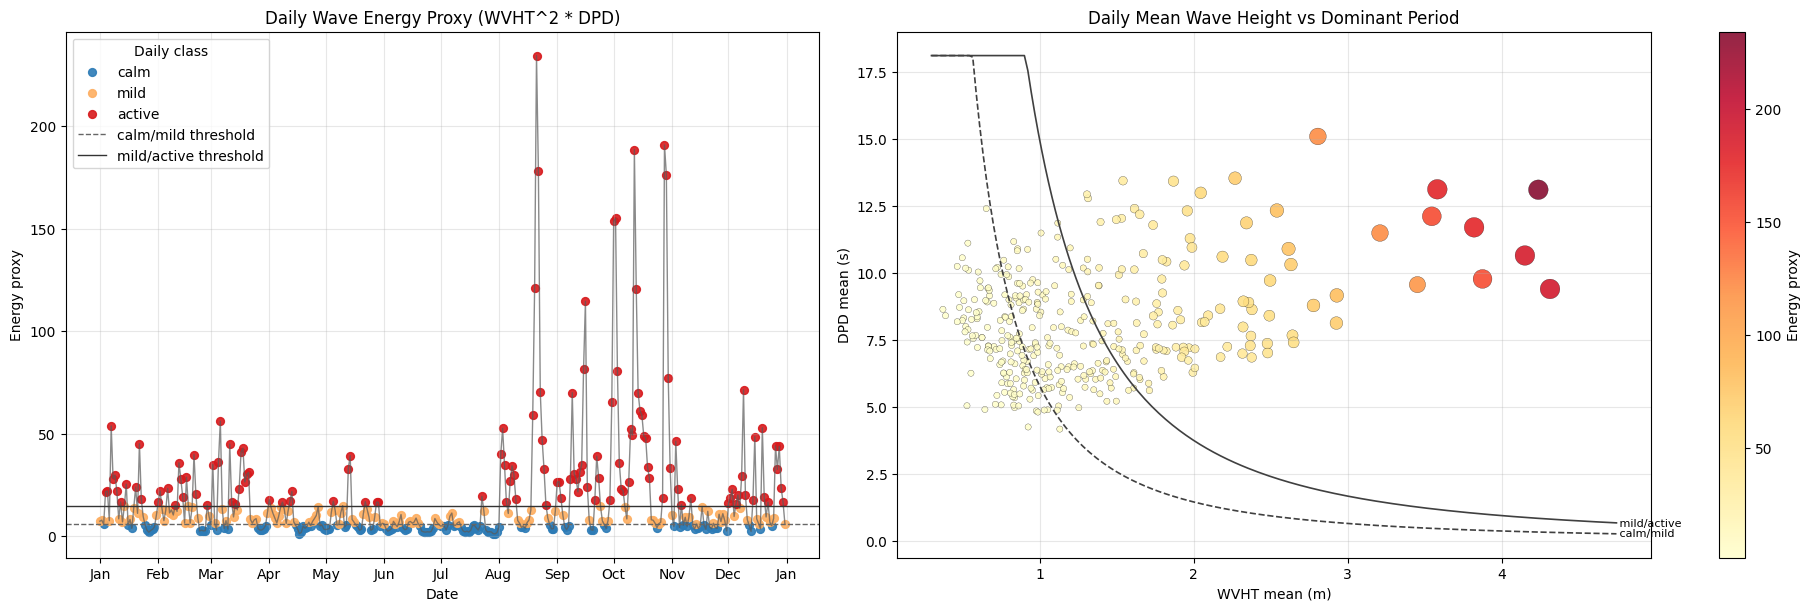

In [14]:
# Visualization 1 (fixed): clear daily timeline + WVHT/DPD phase-space
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

class_colors = {"calm": "#2c7bb6", "mild": "#fdae61", "active": "#d7191c"}

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# Left panel: daily energy timeline (date axis)
ax0 = axes[0]
ax0.plot(daily["date_dt"], daily["energy_mean"], color="0.35", linewidth=1.0, alpha=0.7)
for cls, sub in daily.groupby("energy_class"):
    ax0.scatter(
        sub["date_dt"],
        sub["energy_mean"],
        s=32,
        color=class_colors.get(str(cls), "0.5"),
        label=str(cls),
        alpha=0.9,
    )

ax0.axhline(q_low, color="0.4", linestyle="--", linewidth=1.0, label="calm/mild threshold")
ax0.axhline(q_high, color="0.2", linestyle="-", linewidth=1.0, label="mild/active threshold")
ax0.set_title("Daily Wave Energy Proxy (WVHT^2 * DPD)")
ax0.set_xlabel("Date")
ax0.set_ylabel("Energy proxy")
ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax0.grid(alpha=0.3)
ax0.legend(title="Daily class", loc="upper left")

# Right panel: daily WVHT-DPD space (numeric axes)
ax1 = axes[1]
sc = ax1.scatter(
    daily["wvht_mean"],
    daily["dpd_mean"],
    c=daily["energy_mean"],
    cmap="YlOrRd",
    s=np.clip(daily["energy_mean"] * 1.2, 20, 200),
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)

# Iso-energy guide curves for thresholds
h_grid = np.linspace(max(0.05, float(daily["wvht_mean"].min()) * 0.8), float(daily["wvht_mean"].max()) * 1.1, 200)
for E, ls, txt in [(q_low, "--", "calm/mild"), (q_high, "-", "mild/active")]:
    p_curve = E / (h_grid ** 2)
    p_curve = np.clip(p_curve, 0, daily["dpd_mean"].max() * 1.2)
    ax1.plot(h_grid, p_curve, ls=ls, color="0.25", linewidth=1.2)
    ax1.text(h_grid[-1], p_curve[-1], f" {txt}", fontsize=8, va="center")

ax1.set_title("Daily Mean Wave Height vs Dominant Period")
ax1.set_xlabel("WVHT mean (m)")
ax1.set_ylabel("DPD mean (s)")
ax1.grid(alpha=0.3)
fig.colorbar(sc, ax=ax1, label="Energy proxy")

plt.show()

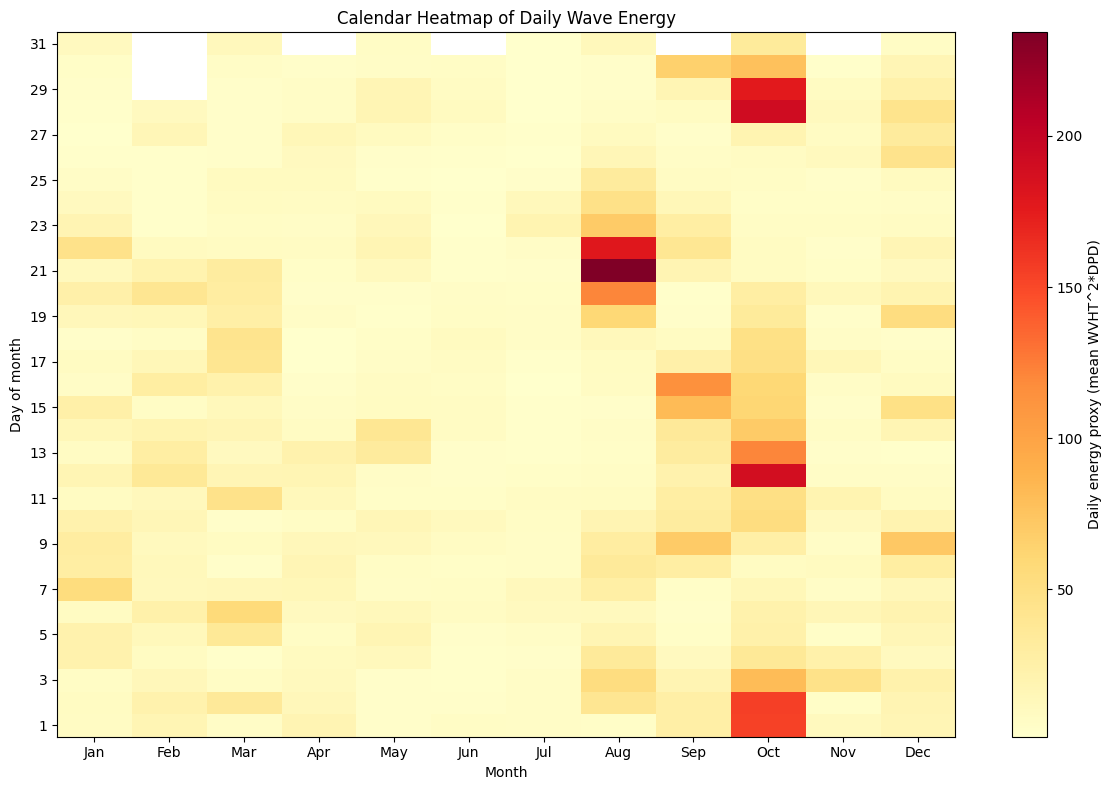

Top 10 most active days:


,date,energy_mean,energy_class,wvht_mean,dpd_mean,height_state,n_obs
232,2025-08-21,234.303325,active,4.236875,13.109583,Very rough+,48
300,2025-10-28,190.725323,active,4.312708,9.402917,Very rough+,48
284,2025-10-12,188.502717,active,4.149792,10.652917,Very rough+,48
233,2025-08-22,178.155504,active,3.581250,13.125625,Rough,48
301,2025-10-29,176.255150,active,3.820000,11.703958,Rough,48
274,2025-10-02,154.907309,active,3.545417,12.116667,Rough,48
273,2025-10-01,153.558385,active,3.874792,9.777708,Rough,48
231,2025-08-20,121.076339,active,2.806042,15.100000,Rough,48
285,2025-10-13,120.646743,active,3.209167,11.492083,Rough,48
258,2025-09-16,114.519428,active,3.452083,9.565000,Rough,48


Top 10 calmest days:


,date,energy_mean,energy_class,wvht_mean,dpd_mean,height_state,n_obs
210,2025-07-30,1.201422,calm,0.372500,8.641458,Smooth,48
209,2025-07-29,1.277438,calm,0.389375,8.405000,Smooth,48
106,2025-04-17,1.310620,calm,0.528542,5.041250,Slight,48
211,2025-07-31,1.844931,calm,0.465417,8.180000,Smooth,48
107,2025-04-18,1.865296,calm,0.554375,6.255208,Slight,48
26,2025-01-27,1.965007,calm,0.530000,7.421458,Slight,48
173,2025-06-23,2.018365,calm,0.480000,8.713333,Smooth,48
196,2025-07-16,2.039833,calm,0.645000,4.902917,Slight,48
206,2025-07-26,2.053174,calm,0.498958,8.221458,Smooth,48
175,2025-06-25,2.071614,calm,0.474792,9.191875,Smooth,48


In [15]:
# Visualization 2: Calendar-style heatmap + top/bottom day tables
import calendar

daily_plot = daily.copy()
daily_plot["month"] = pd.to_datetime(daily_plot["date"]).dt.month
daily_plot["day"] = pd.to_datetime(daily_plot["date"]).dt.day

energy_cal = daily_plot.pivot(index="day", columns="month", values="energy_mean")

plt.figure(figsize=(12, 8))
plt.imshow(energy_cal, aspect="auto", origin="lower", cmap="YlOrRd")
plt.colorbar(label="Daily energy proxy (mean WVHT^2*DPD)")

plt.xticks(ticks=np.arange(12), labels=[calendar.month_abbr[i] for i in range(1, 13)])
plt.yticks(ticks=np.arange(0, 31, 2), labels=np.arange(1, 32, 2))
plt.xlabel("Month")
plt.ylabel("Day of month")
plt.title("Calendar Heatmap of Daily Wave Energy")
plt.tight_layout()
plt.show()

summary_cols = ["date", "energy_mean", "energy_class", "wvht_mean", "dpd_mean", "height_state", "n_obs"]

print("Top 10 most active days:")
display(daily.sort_values("energy_mean", ascending=False)[summary_cols].head(10))

print("Top 10 calmest days:")
display(daily.sort_values("energy_mean", ascending=True)[summary_cols].head(10))